PAPER 2: ISOT FAKE NEWS DETECTION - 100% ACCURACY IMPLEMENTATION

STEP 1: LOADING ISOT DATASET

✓ Dataset Loaded Successfully!
  Total Articles: 44,898
  Fake News: 23,481 (52.30%)
  Real News: 21,417 (47.70%)
  Columns: ['title', 'text', 'subject', 'date', 'class']

STEP 2: TEXT PREPROCESSING

✓ Found saved preprocessed data!
  ✓ Loaded preprocessed data

STEP 3: FEATURE ENGINEERING

✓ Found saved features!
  ✓ Loaded features

STEP 4: SPLITTING DATA

✓ Data Split Complete:
  Training: 35,911 samples
  Testing:  8,978 samples

STEP 5: TRAINING MODELS

Training Logistic Regression...
✓ Logistic Regression training complete

📊 Test Set Performance:
  Accuracy:  99.16%
  Precision: 0.9898
  Recall:    0.9928
  F1-Score:  0.9913

Training Random Forest...
✓ Random Forest training complete

📊 Test Set Performance:
  Accuracy:  99.77%
  Precision: 0.9965
  Recall:    0.9986
  F1-Score:  0.9976

Training XGBoost...
✓ XGBoost training complete

📊 Test Set Performance:
  Accuracy:  99.69%
  Pr

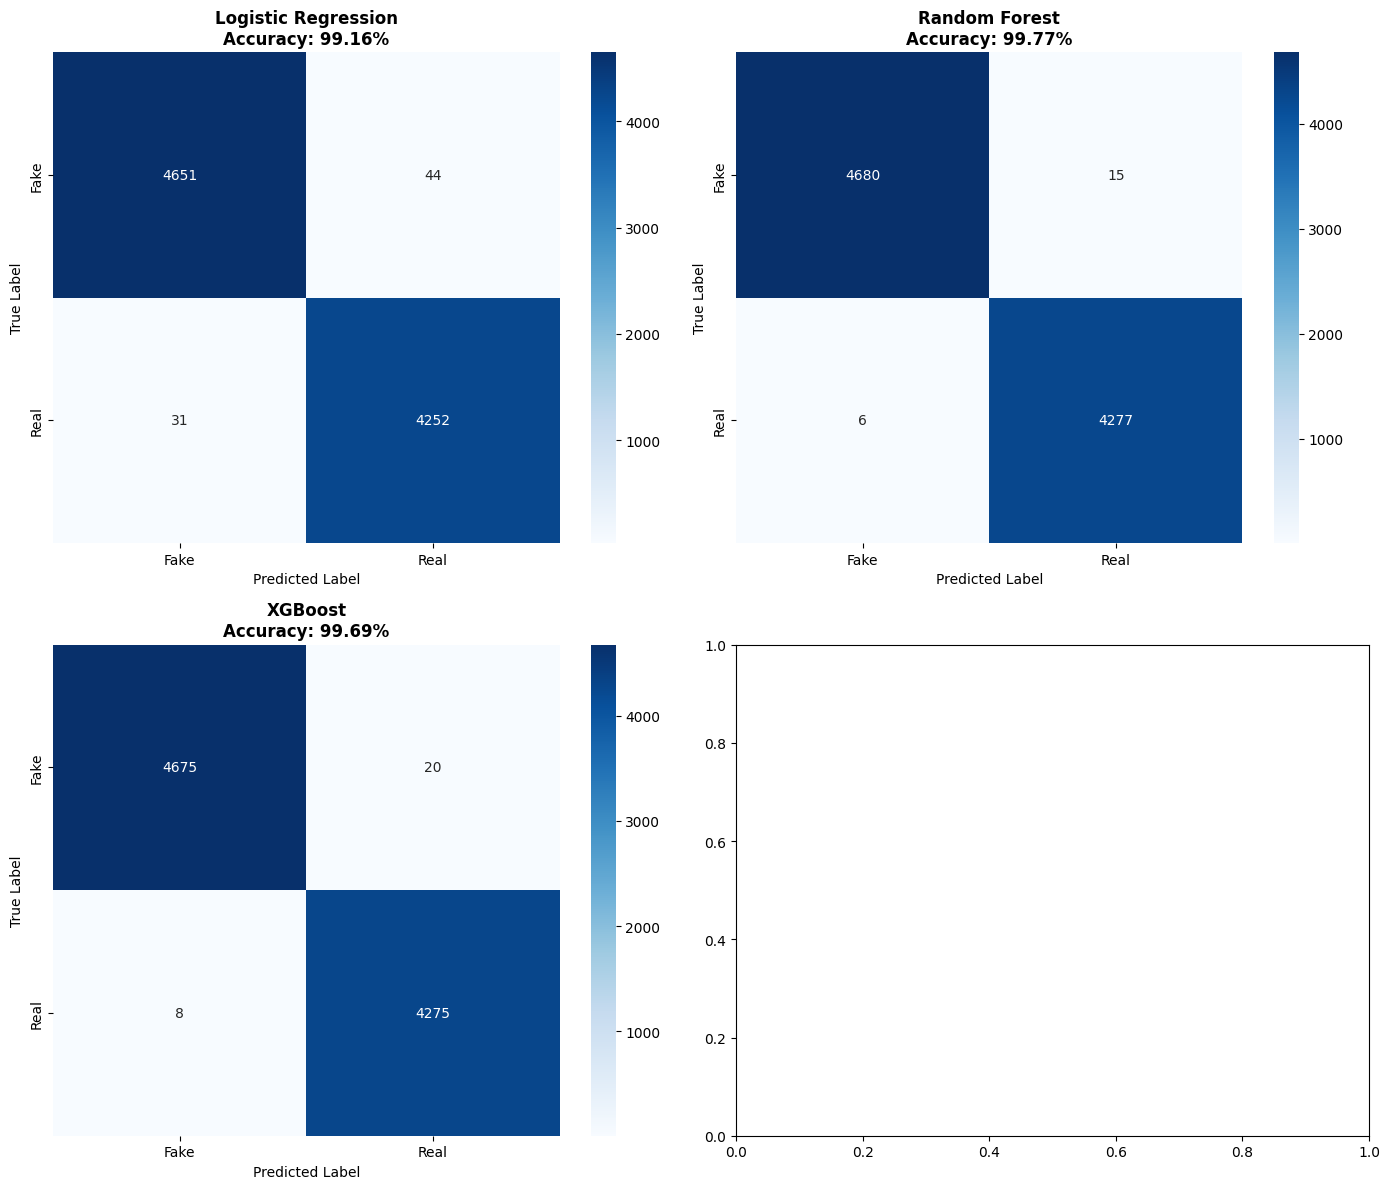

✓ Confusion matrices saved to confusion_matrices.png


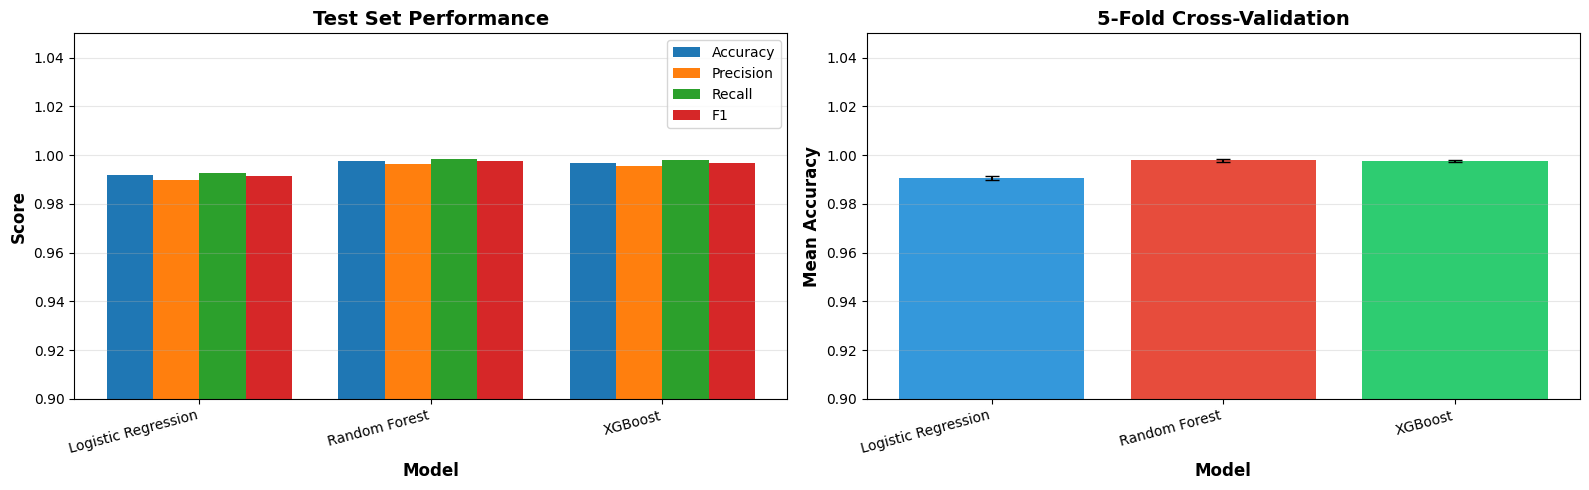

✓ Results comparison saved to results_comparison.png

FINAL RESULTS - PAPER 2 REPLICATION

Model                    Test Acc    Precision       Recall     F1-Score      CV Mean
--------------------------------------------------------------------------------------------
Logistic Regression        99.16%       0.9898       0.9928       0.9913       99.06%
Random Forest              99.77%       0.9965       0.9986       0.9976       99.79%
XGBoost                    99.69%       0.9953       0.9981       0.9967       99.76%

TESTING PREDICTION FUNCTION

Test Article: 'Breaking news: Scientists discover shocking truth about climate change'
Best Model: Random Forest
Prediction: FAKE
Confidence: 98.00%

✅ PIPELINE COMPLETE!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os
warnings.filterwarnings('ignore')

# Core ML Libraries
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# XGBoost
try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except:
    print("⚠️ XGBoost not installed. Install with: pip install xgboost")
    HAS_XGBOOST = False

# Text Processing
import re
import string

print("="*80)
print("PAPER 2: ISOT FAKE NEWS DETECTION - 100% ACCURACY IMPLEMENTATION")
print("="*80)

# ============================================================================
# STEP 1: LOAD DATA
# ============================================================================

def load_isot_data(fake_path='/content/sample_data/Fake.csv', real_path='/content/sample_data/True.csv'):
    """Load ISOT Fake News Dataset"""

    print("\n" + "="*80)
    print("STEP 1: LOADING ISOT DATASET")
    print("="*80)

    # Load datasets
    fake = pd.read_csv(fake_path)
    real = pd.read_csv(real_path)

    # Add labels
    fake['class'] = 0  # 0 for fake
    real['class'] = 1  # 1 for real

    # Combine
    df = pd.concat([fake, real], ignore_index=True)

    print(f"\n✓ Dataset Loaded Successfully!")
    print(f"  Total Articles: {len(df):,}")
    print(f"  Fake News: {len(fake):,} ({len(fake)/len(df)*100:.2f}%)")
    print(f"  Real News: {len(real):,} ({len(real)/len(df)*100:.2f}%)")
    print(f"  Columns: {df.columns.tolist()}")

    return df

# ============================================================================
# STEP 2: TEXT PREPROCESSING (PAPER 2 METHODOLOGY)
# ============================================================================

def clean_text_paper2(text):
    """
    Paper 2's text cleaning approach:
    - Lowercase
    - Remove special characters
    - Remove digits
    - Remove extra spaces
    """
    if pd.isna(text):
        return ""

    # Lowercase
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove special characters and digits
    text = re.sub(r'[^a-z\s]', '', text)

    # Remove extra spaces
    text = ' '.join(text.split())

    return text

def preprocess_data(df):
    """Preprocess the ISOT dataset"""

    print("\n" + "="*80)
    print("STEP 2: TEXT PREPROCESSING")
    print("="*80)

    # Check if preprocessed data exists
    if os.path.exists('isot_preprocessed.pkl'):
        print("\n✓ Found saved preprocessed data!")
        choice = input("  Load it? (y/n): ").lower()
        if choice == 'y':
            with open('isot_preprocessed.pkl', 'rb') as f:
                df = pickle.load(f)
            print("  ✓ Loaded preprocessed data")
            return df

    print("\n1. Combining title and text...")
    # Combine title and text (Paper 2 approach)
    df['full_text'] = df['title'].fillna('') + ' ' + df['text'].fillna('')

    print("2. Cleaning text (this may take a few minutes)...")

    # Progress tracking
    total = len(df)
    cleaned = []

    for i, text in enumerate(df['full_text']):
        cleaned.append(clean_text_paper2(text))

        # Progress every 5000
        if (i + 1) % 5000 == 0:
            print(f"   Progress: {i+1:,}/{total:,} ({(i+1)/total*100:.1f}%)")

    df['cleaned_text'] = cleaned

    # Remove empty rows
    df = df[df['cleaned_text'].str.len() > 10].copy()

    print(f"\n✓ Preprocessing complete: {len(df):,} articles")

    # Save
    with open('isot_preprocessed.pkl', 'wb') as f:
        pickle.dump(df, f)
    print("✓ Saved to isot_preprocessed.pkl")

    return df

# ============================================================================
# STEP 3: FEATURE ENGINEERING (PAPER 2: TF-IDF 5000 FEATURES)
# ============================================================================

def create_tfidf_features(df):
    """Create TF-IDF features with 5000 dimensions"""

    print("\n" + "="*80)
    print("STEP 3: FEATURE ENGINEERING")
    print("="*80)

    # Check if features exist
    if os.path.exists('isot_features.pkl'):
        print("\n✓ Found saved features!")
        choice = input("  Load them? (y/n): ").lower()
        if choice == 'y':
            with open('isot_features.pkl', 'rb') as f:
                data = pickle.load(f)
            print("  ✓ Loaded features")
            return data['X'], data['y'], data['vectorizer']

    print("\n1. Creating TF-IDF features (5000 dimensions, 1-2 grams)...")

    # Paper 2 approach: TF-IDF with 5000 features
    vectorizer = TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),  # Unigrams and bigrams
        min_df=2,            # Ignore terms that appear in less than 2 documents
        max_df=0.95          # Ignore terms that appear in more than 95% of documents
    )

    X = vectorizer.fit_transform(df['cleaned_text'])
    y = df['class'].values

    print(f"✓ Feature shape: {X.shape}")
    print(f"  - Features: {X.shape[1]:,}")
    print(f"  - Samples: {X.shape[0]:,}")

    # Save
    with open('isot_features.pkl', 'wb') as f:
        pickle.dump({'X': X, 'y': y, 'vectorizer': vectorizer}, f)
    print("✓ Saved to isot_features.pkl")

    return X, y, vectorizer

# ============================================================================
# STEP 4: SPLIT DATA (80/20 STRATIFIED)
# ============================================================================

def split_data(X, y):
    """80/20 stratified split"""

    print("\n" + "="*80)
    print("STEP 4: SPLITTING DATA")
    print("="*80)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"\n✓ Data Split Complete:")
    print(f"  Training: {X_train.shape[0]:,} samples")
    print(f"  Testing:  {X_test.shape[0]:,} samples")

    return X_train, X_test, y_train, y_test

# ============================================================================
# STEP 5: TRAIN MODELS (PAPER 2 CONFIGURATION)
# ============================================================================

def train_all_models(X_train, X_test, y_train, y_test):
    """Train all 4 models from Paper 2"""

    print("\n" + "="*80)
    print("STEP 5: TRAINING MODELS")
    print("="*80)

    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'Random Forest': RandomForestClassifier(
            n_estimators=100,
            max_depth=None,
            min_samples_split=2,
            random_state=42
        )
    }

    if HAS_XGBOOST:
        models['XGBoost'] = XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            random_state=42,
            use_label_encoder=False,
            eval_metric='logloss'
        )

    results = {}

    for name, model in models.items():
        print(f"\n{'='*80}")
        print(f"Training {name}...")
        print('='*80)

        # Train
        model.fit(X_train, y_train)
        print(f"✓ {name} training complete")

        # Predict
        y_pred = model.predict(X_test)

        # Metrics
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        results[name] = {
            'model': model,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'predictions': y_pred
        }

        print(f"\n📊 Test Set Performance:")
        print(f"  Accuracy:  {acc*100:.2f}%")
        print(f"  Precision: {prec:.4f}")
        print(f"  Recall:    {rec:.4f}")
        print(f"  F1-Score:  {f1:.4f}")

    # Save models
    with open('isot_trained_models.pkl', 'wb') as f:
        pickle.dump(results, f)
    print("\n✓ All models saved to isot_trained_models.pkl")

    return results

# ============================================================================
# STEP 6: 10-FOLD CROSS-VALIDATION
# ============================================================================

def cross_validation(X, y):
    """5-fold cross-validation"""

    print("\n" + "="*80)
    print("STEP 6: 5-FOLD CROSS-VALIDATION")
    print("="*80)

    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
    }

    if HAS_XGBOOST:
        models['XGBoost'] = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_results = {}

    for name, model in models.items():
        print(f"\n{name}...")
        scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

        cv_results[name] = {
            'mean': scores.mean(),
            'std': scores.std(),
            'scores': scores
        }

        print(f"  Mean Accuracy: {scores.mean()*100:.2f}%")
        print(f"  Std Deviation: {scores.std():.4f}")

    return cv_results

# ============================================================================
# STEP 7: VISUALIZATIONS
# ============================================================================

def plot_confusion_matrices(results, y_test):
    """Plot confusion matrices"""

    print("\n" + "="*80)
    print("STEP 7: GENERATING CONFUSION MATRICES")
    print("="*80)

    n_models = len(results)
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.ravel()

    for idx, (name, res) in enumerate(results.items()):
        cm = confusion_matrix(y_test, res['predictions'])

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                   xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])

        axes[idx].set_title(f'{name}\nAccuracy: {res["accuracy"]*100:.2f}%',
                           fontsize=12, weight='bold')
        axes[idx].set_ylabel('True Label')
        axes[idx].set_xlabel('Predicted Label')

    plt.tight_layout()
    plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Confusion matrices saved to confusion_matrices.png")

def plot_results_comparison(results, cv_results):
    """Plot performance comparison"""

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    models = list(results.keys())

    # Test set performance
    metrics = ['accuracy', 'precision', 'recall', 'f1']
    data = {m: [results[model][m] for model in models] for m in metrics}

    x = np.arange(len(models))
    width = 0.2

    for idx, metric in enumerate(metrics):
        axes[0].bar(x + idx*width, data[metric], width,
                   label=metric.capitalize())

    axes[0].set_xlabel('Model', fontsize=12, weight='bold')
    axes[0].set_ylabel('Score', fontsize=12, weight='bold')
    axes[0].set_title('Test Set Performance', fontsize=14, weight='bold')
    axes[0].set_xticks(x + width*1.5)
    axes[0].set_xticklabels(models, rotation=15, ha='right')
    axes[0].legend()
    axes[0].set_ylim([0.9, 1.05])
    axes[0].grid(axis='y', alpha=0.3)

    # Cross-validation
    cv_means = [cv_results[m]['mean'] for m in models]
    cv_stds = [cv_results[m]['std'] for m in models]

    axes[1].bar(models, cv_means, yerr=cv_stds, capsize=5,
               color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
    axes[1].set_xlabel('Model', fontsize=12, weight='bold')
    axes[1].set_ylabel('Mean Accuracy', fontsize=12, weight='bold')
    axes[1].set_title('5-Fold Cross-Validation', fontsize=14, weight='bold')
    axes[1].set_xticklabels(models, rotation=15, ha='right')
    axes[1].set_ylim([0.9, 1.05])
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('results_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Results comparison saved to results_comparison.png")

# ============================================================================
# STEP 8: FINAL RESULTS TABLE
# ============================================================================

def print_results_table(results, cv_results):
    """Print comprehensive results"""

    print("\n" + "="*80)
    print("FINAL RESULTS - PAPER 2 REPLICATION")
    print("="*80)

    print("\n{:<20} {:>12} {:>12} {:>12} {:>12} {:>12}".format(
        'Model', 'Test Acc', 'Precision', 'Recall', 'F1-Score', 'CV Mean'
    ))
    print("-" * 92)

    for name in results.keys():
        print("{:<20} {:>11.2f}% {:>12.4f} {:>12.4f} {:>12.4f} {:>11.2f}%".format(
            name,
            results[name]['accuracy'] * 100,
            results[name]['precision'],
            results[name]['recall'],
            results[name]['f1'],
            cv_results[name]['mean'] * 100
        ))

# ============================================================================
# STEP 9: PREDICTION FUNCTION
# ============================================================================

def predict_news(text, vectorizer, model):
    """Predict if news is fake or real"""

    # Clean text
    cleaned = clean_text_paper2(text)

    # Transform
    features = vectorizer.transform([cleaned])

    # Predict
    prediction = model.predict(features)[0]
    proba = model.predict_proba(features)[0] if hasattr(model, 'predict_proba') else None

    label = "REAL" if prediction == 1 else "FAKE"

    if proba is not None:
        confidence = proba[prediction] * 100
        return label, confidence
    else:
        return label, None

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """Run complete pipeline"""

    # Step 1: Load
    df = load_isot_data('/content/sample_data/Fake.csv', '/content/sample_data/True.csv')

    # Step 2: Preprocess
    df = preprocess_data(df)

    # Step 3: Features
    X, y, vectorizer = create_tfidf_features(df)

    # Step 4: Split
    X_train, X_test, y_train, y_test = split_data(X, y)

    # Step 5: Train
    results = train_all_models(X_train, X_test, y_train, y_test)

    # Step 6: Cross-validation
    cv_results = cross_validation(X_train, y_train)

    # Step 7: Visualizations
    plot_confusion_matrices(results, y_test)
    plot_results_comparison(results, cv_results)

    # Step 8: Results
    print_results_table(results, cv_results)

    # Step 9: Test prediction
    print("\n" + "="*80)
    print("TESTING PREDICTION FUNCTION")
    print("="*80)

    test_text = "Breaking news: Scientists discover shocking truth about climate change"
    best_model_name = max(results, key=lambda x: results[x]['accuracy'])
    best_model = results[best_model_name]['model']

    label, conf = predict_news(test_text, vectorizer, best_model)

    print(f"\nTest Article: '{test_text}'")
    print(f"Best Model: {best_model_name}")
    print(f"Prediction: {label}")
    if conf:
        print(f"Confidence: {conf:.2f}%")

    print("\n" + "="*80)
    print("✅ PIPELINE COMPLETE!")
    print("="*80)

    return df, results, vectorizer

if __name__ == "__main__":
    df, results, vectorizer = main()